# 02. Exploratory data analysis

**Owner:** Roger  \
**Inputs:** `data/processed/panel_municipality_year.parquet` and
`data/processed/fire_panel_municipality_year.parquet`, both built by `make data`  \
**Outputs:** figures to `reports/figures/`

## Purpose

Describe the panel before anyone models it: how fires are distributed, when and
where they happen, what burns, and how municipalities differ demographically.

This chapter **describes**. It fits nothing and claims no causation. The
fixed-effects and time-series work is chapter 03; the predictive models are
chapter 04. Where a relationship appears here it is reported as a correlation and
left there.

Provenance, coverage and the data-quality caveats are **chapter 01** and are not
repeated. One is load-bearing enough to restate: `burned_ha_*` covers 2017–2025
and `burned_ha_*_ignited` covers 2001–2016, so no ICNF burned-area column spans
2017.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

# Make the src-layout package importable when the notebook kernel is not installed with -e .
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wildfires.io import load_fire_panel, load_municipalities, load_panel
from wildfires.presentation import draw_quintiles, quintile_data
from wildfires.viz import apply_theme, choropleth, save_figure

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

panel = load_panel()            # fire x demography, 2019-2024, 1,668 rows
fire_panel = load_fire_panel()  # fire only, 2001-2025, 6,921 rows
panel.shape, fire_panel.shape

((1668, 69), (6921, 45))

## How fires are distributed

Portuguese fire counts are dominated by very small fires, and burned area by very
large ones. Any statistic that ignores this — a mean fire size, an untransformed
regression on burned area — describes almost none of the data.

In [2]:
SIZE_CLASSES = {
    "n_fires_0_1ha": "0–1 ha",
    "n_fires_1_10ha": "1–10 ha",
    "n_fires_10_20ha": "10–20 ha",
    "n_fires_20_50ha": "20–50 ha",
    "n_fires_50_100ha": "50–100 ha",
    "n_fires_100_500ha": "100–500 ha",
    "n_fires_500_1000ha": "500–1000 ha",
    "n_fires_1000_plus_ha": "1000+ ha",
}

counts = fire_panel[list(SIZE_CLASSES)].sum().rename(index=SIZE_CLASSES)
distribution = pd.DataFrame({
    "fires": counts.astype(int),
    "share_pct": (counts / counts.sum() * 100).round(2),
    "cumulative_pct": (counts / counts.sum() * 100).cumsum().round(2),
})
print(f"Total ICNF rural fires 2001-2025: {int(counts.sum()):,}")
distribution

Total ICNF rural fires 2001-2025: 497,477


,fires,share_pct,cumulative_pct
0–1 ha,403988,81.21,81.21
1–10 ha,77639,15.61,96.81
10–20 ha,5415,1.09,97.90
20–50 ha,4706,0.95,98.85
50–100 ha,2313,0.46,99.31
100–500 ha,2437,0.49,99.80
500–1000 ha,473,0.10,99.90
1000+ ha,506,0.10,100.00


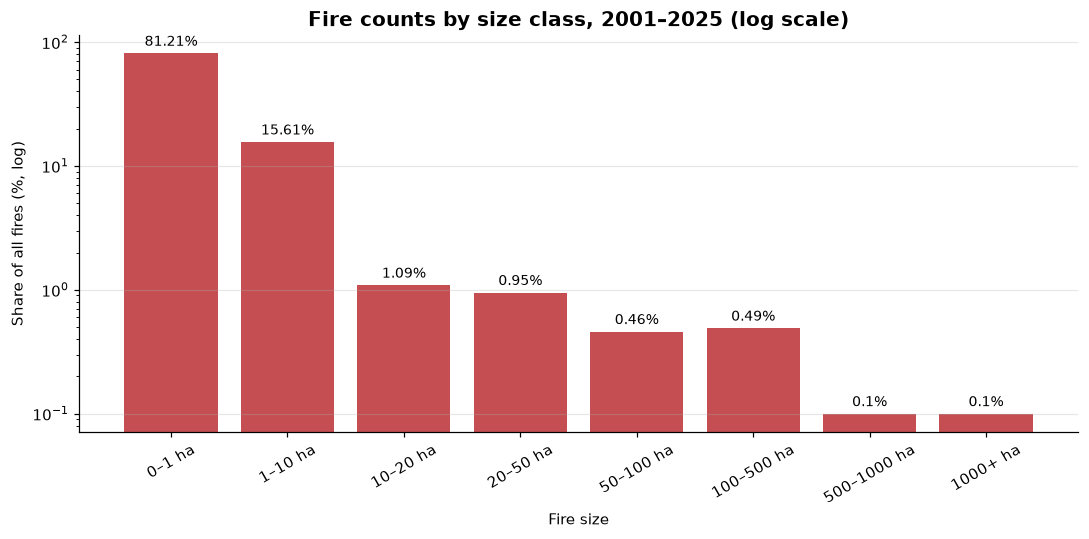

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(distribution.index, distribution.share_pct, color="#C44E52")
ax.set_yscale("log")
ax.set_title("Fire counts by size class, 2001–2025 (log scale)")
ax.set_xlabel("Fire size")
ax.set_ylabel("Share of all fires (%, log)")
ax.tick_params(axis="x", rotation=30)
for x, v in enumerate(distribution.share_pct):
    ax.text(x, v * 1.15, f"{v:g}%", ha="center", fontsize=9)

fig.tight_layout()
save_figure(fig, "fire_size_distribution")
plt.show()

Four fifths of all recorded fires never reach one hectare, and 96.8% stay under
ten. Fires above 500 ha are two in every thousand — and they are the ones that
produce the burned-area totals everything else is built on. **The log scale is
not decoration here; on a linear axis the top six classes are invisible.**

The same skew runs through burn rate, the share of a municipality's own land that
burned in a year.

In [4]:
burn_pct = (panel.burn_rate * 100).dropna()

pd.DataFrame({
    "burn_rate_pct": burn_pct.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(3)
}).T

,count,mean,std,min,25%,50%,75%,90%,99%,max
burn_rate_pct,1666.0,0.97,3.636,0.0,0.014,0.058,0.425,1.889,17.101,50.636


The median municipality-year burns **0.06%** of its own area; the mean is sixteen
times that, and the worst year on record burns just over half the municipality.
A distribution this skewed is why chapter 03 models `log1p` of its outcome.

## The EFFIS detection break

Chapter 01 notes that EFFIS lowered its minimum mapped fire size around 2020.
This is what that looks like, and it is large enough to swamp any real trend.

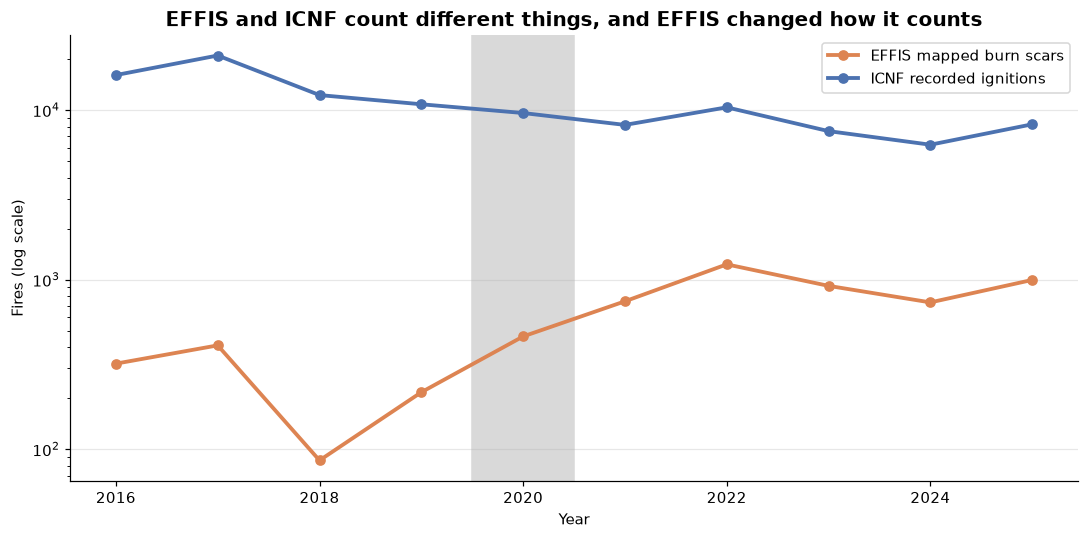

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
effis_mapped,320,410,86,217,463,746,1232,920,735,997
icnf_ignitions,16104,21006,12273,10832,9619,8186,10390,7523,6255,8252


In [5]:
mapped = fire_panel.groupby("year").effis_n_fires.sum(min_count=1).dropna()
icnf = fire_panel.groupby("year").n_fires.sum().loc[mapped.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mapped.index, mapped.values, marker="o", linewidth=2.5,
        color="#DD8452", label="EFFIS mapped burn scars")
ax.plot(icnf.index, icnf.values, marker="o", linewidth=2.5,
        color="#4C72B0", label="ICNF recorded ignitions")
ax.axvspan(2019.5, 2020.5, color="0.85", zorder=0)
ax.set_yscale("log")
ax.set_title("EFFIS and ICNF count different things, and EFFIS changed how it counts")
ax.set_xlabel("Year")
ax.set_ylabel("Fires (log scale)")
ax.legend()

fig.tight_layout()
save_figure(fig, "effis_detection_break")
plt.show()

pd.DataFrame({"effis_mapped": mapped.astype(int), "icnf_ignitions": icnf.astype(int)}).T

Two things to read here.

**The level gap.** ICNF records tens of thousands of ignitions a year; EFFIS maps
hundreds of perimeters. They are not rival estimates of one quantity — ICNF counts
*ignitions*, EFFIS maps *burn scars big enough to see from orbit*. Chapter 01
shows the consequence: 970 of the 981 panel rows with no EFFIS record still had
ICNF fires.

**The break.** EFFIS mapped 86 fires in 2018 and 1,232 in 2022. No plausible
change in fire activity does that. It is a change in what EFFIS chooses to map,
and it means **EFFIS counts must not be compared across 2020** without applying a
constant size floor (`CONVENTIONS["min_fire_ha"]`, 30 ha) first.

## Temporal patterns

With that caveat in hand, ICNF's own series is the one to read for trend — it
spans 2001–2025 on a consistent counting basis, even though its *area* columns
change convention at 2017.

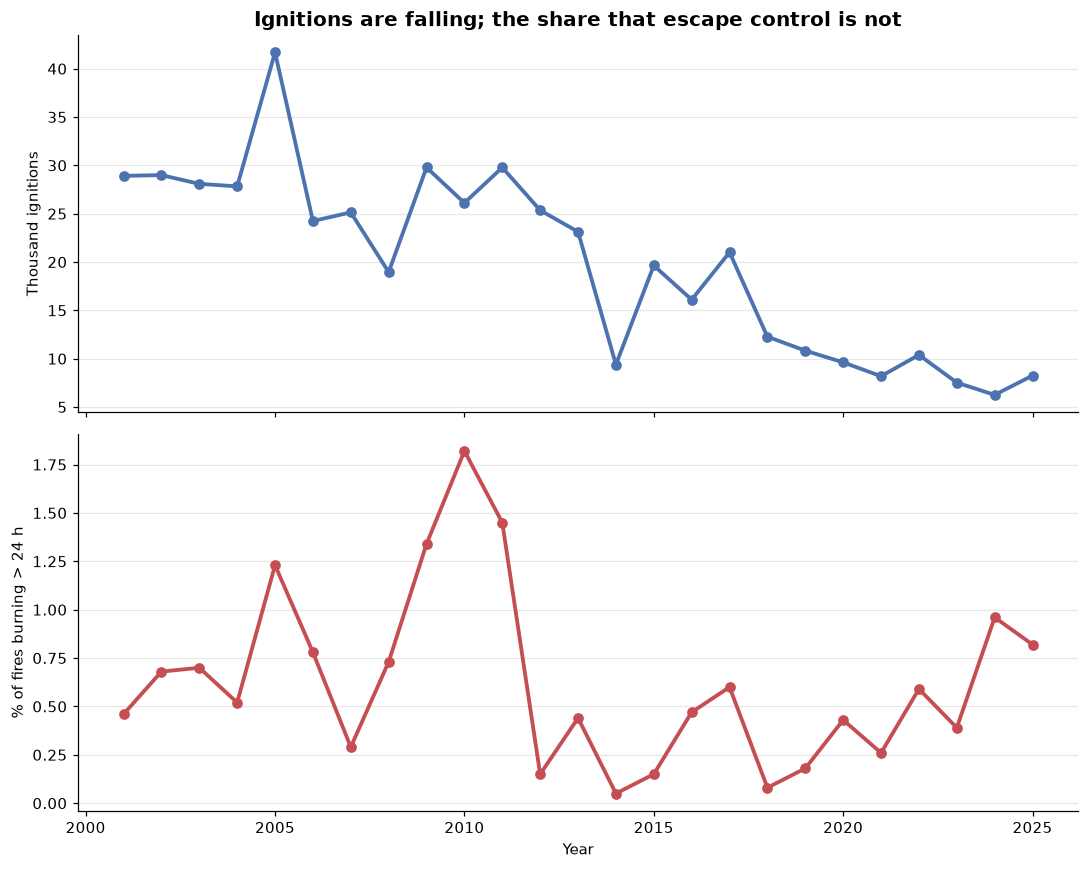

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ignitions,28915.00,28993.00,28087.0,27829.00,41689.00,24243.00,25133.00,18958.00,29783.00,26113.00,29782.00,25352.00,23129.00,9388.00,19643.00,16104.00,21006.0,12273.00,10832.00,9619.00,8186.00,10390.00,7523.00,6255.00,8252.00
pct_over_24h,0.46,0.68,0.7,0.52,1.23,0.78,0.29,0.73,1.34,1.82,1.45,0.15,0.44,0.05,0.15,0.47,0.6,0.08,0.18,0.43,0.26,0.59,0.39,0.96,0.82
large_fires,23.00,18.00,82.0,32.00,64.00,8.00,3.00,0.00,10.00,27.00,6.00,11.00,29.00,3.00,8.00,25.00,63.0,1.00,2.00,11.00,2.00,17.00,4.00,25.00,32.00


In [6]:
yearly = fire_panel.groupby("year").agg(
    ignitions=("n_fires", "sum"),
    long_burning=("n_fires_gt24h", "sum"),
    large_fires=("n_fires_1000_plus_ha", "sum"),
)
yearly["pct_over_24h"] = (yearly.long_burning / yearly.ignitions * 100).round(2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(yearly.index, yearly.ignitions / 1000, marker="o", linewidth=2.5, color="#4C72B0")
ax1.set_ylabel("Thousand ignitions")
ax1.set_title("Ignitions are falling; the share that escape control is not")

ax2.plot(yearly.index, yearly.pct_over_24h, marker="o", linewidth=2.5, color="#C44E52")
ax2.set_ylabel("% of fires burning > 24 h")
ax2.set_xlabel("Year")

fig.tight_layout()
save_figure(fig, "ignitions_and_escape_rate")
plt.show()

yearly[["ignitions", "pct_over_24h", "large_fires"]].T

Ignition counts trend down over the period. The share of fires that burn longer
than 24 hours does not follow them down, and the count of 1000-hectare-plus fires
is driven by a handful of catastrophic years rather than by any trend.

That gap matters for the project's framing: **fewer fires is not the same as less
fire risk.** A landscape that produces fewer but harder-to-stop fires is
consistent with the abandonment hypothesis, and it is not visible in an ignition
count alone.

## Where fires are

Two maps, both averaged over the panel's 2019–2024 window so a single
catastrophic year does not dominate.

278 municipalities, 0 unmatched


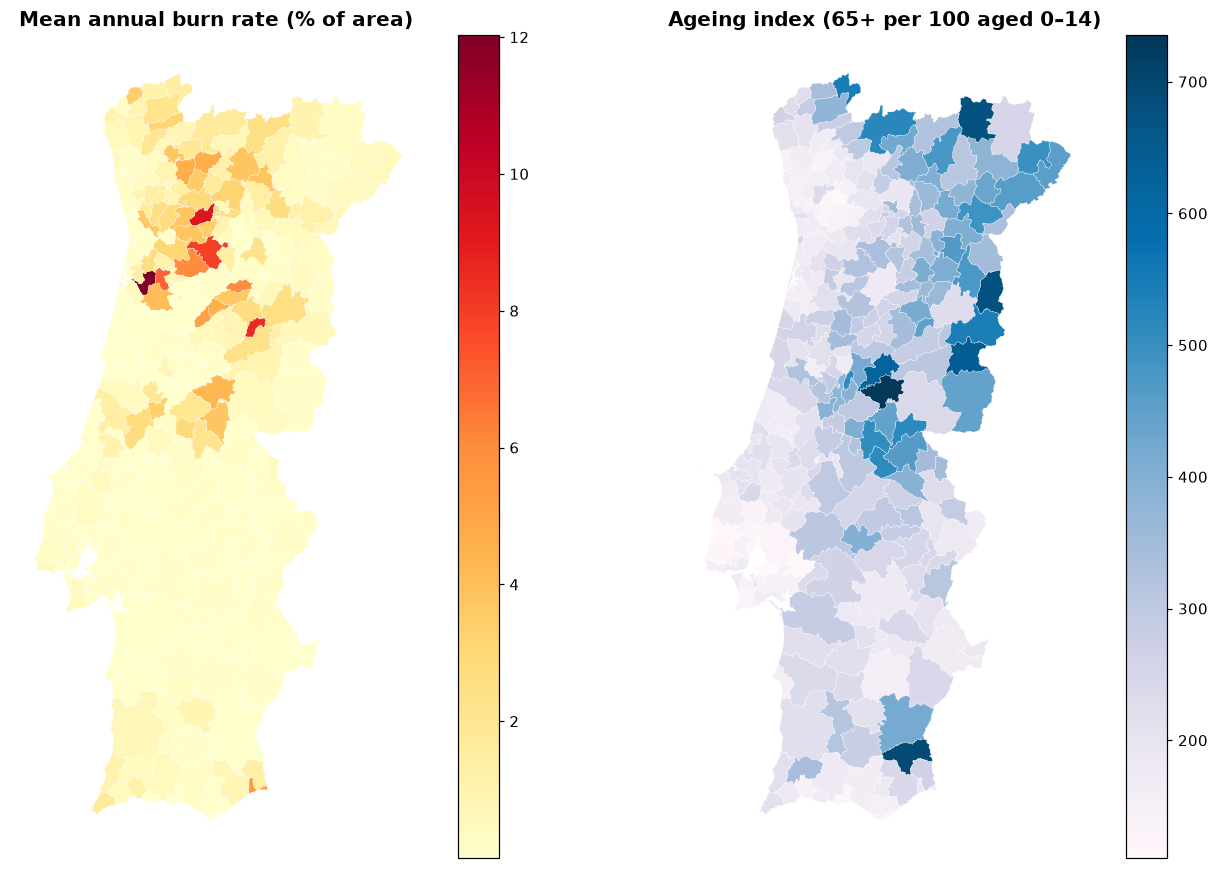

In [7]:
boundaries = load_municipalities(mainland_only=True)[["dtcc", "municipality", "geometry"]]

municipal = panel.groupby("dtcc").agg(
    burn_rate_pct=("burn_rate", lambda s: s.mean() * 100),
    aging_index=("aging_index", "mean"),
    share_65_plus=("share_65_plus", "mean"),
    lc_transit_mean=("lc_transit_mean", "mean"),
    pop_density=("pop_density", "mean"),
).reset_index()

mapped_gdf = boundaries.merge(municipal, on="dtcc", how="left", validate="one_to_one")
print(f"{len(mapped_gdf)} municipalities, {int(mapped_gdf.burn_rate_pct.isna().sum())} unmatched")

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
choropleth(mapped_gdf, "burn_rate_pct", title="Mean annual burn rate (% of area)", ax=axes[0])
choropleth(mapped_gdf, "aging_index", title="Ageing index (65+ per 100 aged 0–14)",
           ax=axes[1], cmap="PuBu")

fig.tight_layout()
save_figure(fig, "burn_rate_and_ageing_maps")
plt.show()

The two maps do **not** show the same geography, and the difference is the most
useful thing in this chapter.

Burning concentrates in the north and centre and is close to absent across the
Alentejo. Ageing does not follow that line: the interior is old from Bragança all
the way down through Portalegre, including the southern districts that barely
burn. The oldest district in the country, Bragança, has a mean burn rate below the
national average.

Splitting at the Tejo makes the problem explicit.

In [8]:
geo = load_municipalities(mainland_only=True)[["dtcc", "district", "geometry"]].copy()

# Representative point computed in a metric CRS, then read back as latitude.
geo["lat"] = geo.to_crs(3763).geometry.representative_point().to_crs(4326).y
# The Tejo is the conventional north/south divide in Portuguese fire geography.
geo["half"] = geo.lat.ge(39.4).map({True: "north of Tejo", False: "south of Tejo"})

halves = geo.merge(municipal, on="dtcc", how="left", validate="one_to_one")

summary = halves.groupby("half").agg(
    municipalities=("dtcc", "size"),
    mean_burn_pct=("burn_rate_pct", "mean"),
    median_burn_pct=("burn_rate_pct", "median"),
    mean_aging=("aging_index", "mean"),
)
summary["rho_within"] = halves.groupby("half").apply(
    lambda g: g.aging_index.corr(g.burn_rate_pct, method="spearman"),
    include_groups=False,
)
summary.round(3)

,municipalities,mean_burn_pct,median_burn_pct,mean_aging,rho_within
half,,,,,
north of Tejo,181,1.348,0.558,292.336,0.02
south of Tejo,97,0.261,0.080,212.644,-0.24


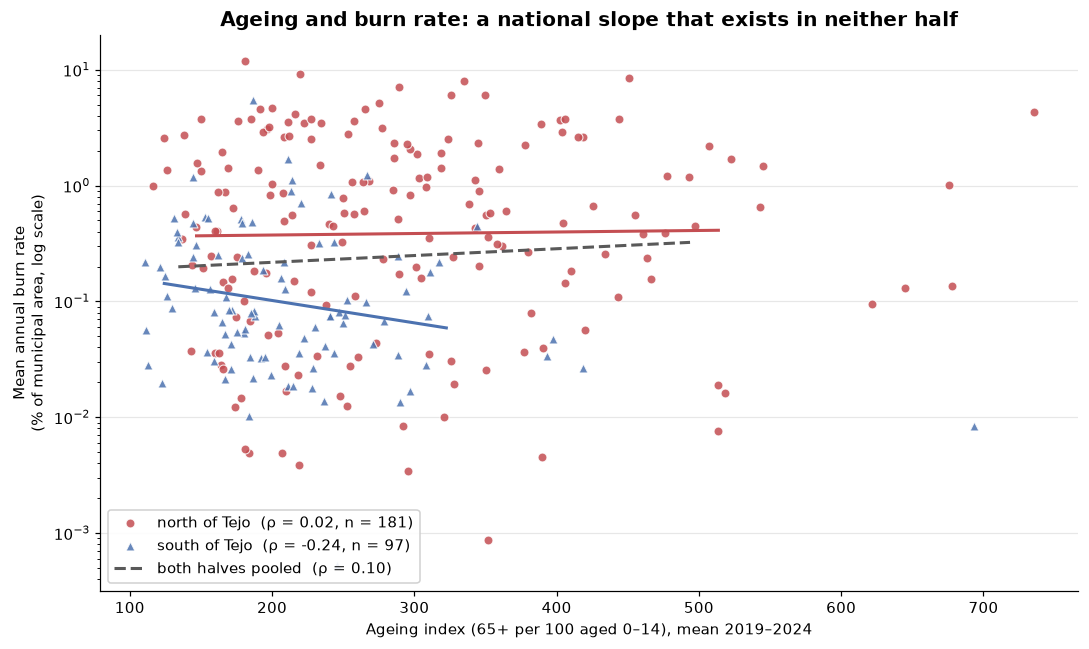

In [9]:
COLOURS = {"north of Tejo": "#C44E52", "south of Tejo": "#4C72B0"}
MARKERS = {"north of Tejo": "o", "south of Tejo": "^"}

fitted = halves.dropna(subset=["aging_index", "burn_rate_pct"])


def trend(ax, x, y, **kwargs):
    """Least squares in log space — monotone, so its sign matches Spearman's.

    Drawn only across the central 90% of x, so a sparse tail cannot make a slope
    look better supported than it is.
    """
    slope, intercept = np.polyfit(x, np.log10(y), 1)
    xs = np.linspace(*np.percentile(x, [5, 95]), 100)
    ax.plot(xs, 10 ** (intercept + slope * xs), linewidth=2, **kwargs)


fig, ax = plt.subplots(figsize=(10, 6))

for half, group in fitted.groupby("half"):
    ax.scatter(group.aging_index, group.burn_rate_pct,
               s=34, marker=MARKERS[half], color=COLOURS[half],
               edgecolor="white", linewidth=0.7, alpha=0.85, zorder=3,
               label=f"{half}  (\u03c1 = {summary.loc[half, 'rho_within']:.2f}, n = {len(group)})")
    trend(ax, group.aging_index, group.burn_rate_pct, color=COLOURS[half], zorder=4)

# The pooled line is the point of the figure: it rises through two clouds that do
# not rise themselves.
rho_all = fitted.aging_index.corr(fitted.burn_rate_pct, method="spearman")
trend(ax, fitted.aging_index, fitted.burn_rate_pct, color="0.35", linestyle="--",
      zorder=5, label=f"both halves pooled  (\u03c1 = {rho_all:.2f})")

ax.set_yscale("log")
ax.set_title("Ageing and burn rate: a national slope that exists in neither half")
ax.set_xlabel("Ageing index (65+ per 100 aged 0\u201314), mean 2019\u20132024")
ax.set_ylabel("Mean annual burn rate\n(% of municipal area, log scale)")
ax.legend(loc="lower left", frameon=True, framealpha=0.9)

fig.tight_layout()
save_figure(fig, "ageing_vs_burn_rate_by_half")
plt.show()

The north is both older *and* burnier than the south, which is what produces the
positive national correlation. But **inside** either half the relationship
disappears: ρ ≈ 0.02 in the north, and ρ ≈ −0.24 in the south, where the older
municipalities burn *less*.

The national ρ ≈ 0.10 reported later is therefore mostly a composition effect —
two regions differing in both variables at once — rather than a within-place
association between ageing and fire. That is exactly the confound municipality
fixed effects exist to absorb, and it is why chapter 03 uses them. Read naively,
the same number would support a causal story the geography does not.

The scatter above is the same fact drawn rather than tabulated. The northern cloud
sits high and almost flat; the southern one sits lower and tilts downwards; and the
pooled dashed line rising through both has a slope that neither half possesses. A
national coefficient can be produced entirely by the gap between two groups without
describing anything that happens inside either of them.

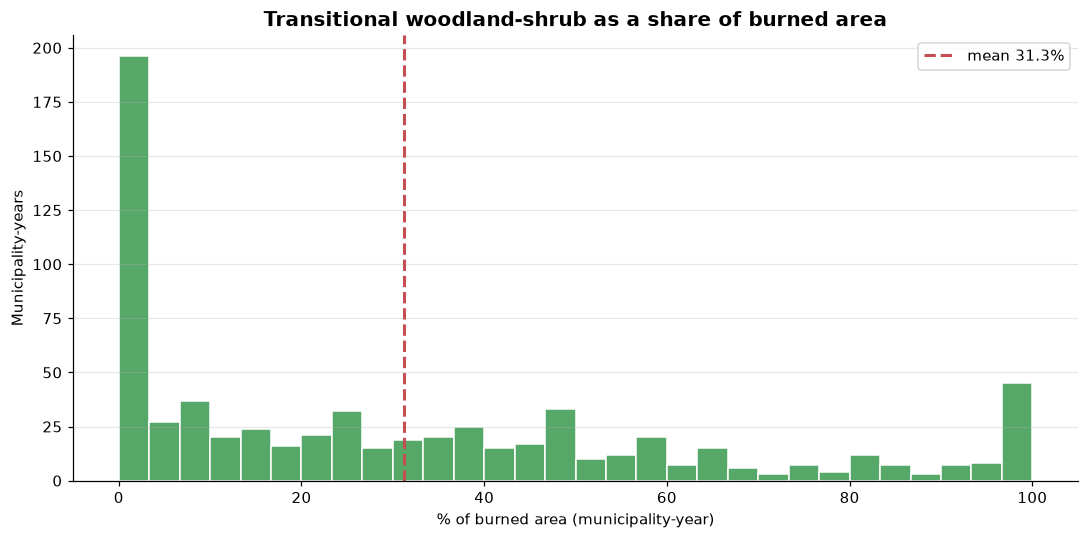

,count,mean,std,min,25%,50%,75%,max
lc_transit_mean,683.0,31.25,31.57,0.0,0.0,23.37,50.0,100.0


In [10]:
transit = panel.lc_transit_mean.dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(transit, bins=30, color="#55A868", edgecolor="white")
ax.axvline(transit.mean(), color="#C44E52", linestyle="--", linewidth=2,
           label=f"mean {transit.mean():.1f}%")
ax.set_title("Transitional woodland-shrub as a share of burned area")
ax.set_xlabel("% of burned area (municipality-year)")
ax.set_ylabel("Municipality-years")
ax.legend()

fig.tight_layout()
save_figure(fig, "transitional_woodland_share")
plt.show()

transit.describe().round(2).to_frame("lc_transit_mean").T

Across the municipality-years EFFIS mapped, transitional woodland-shrub averages
**31.3%** of burned area — a large share for a single CORINE class, and the
empirical hook the abandonment hypothesis hangs on.

**But read the column carefully, because it does not say what it looks like it
says.** `lc_transit_mean` is the composition of *burn scars*, not of
municipalities. It is measured only where something burned, and it describes what
the fire consumed. It therefore cannot answer "do abandoned municipalities burn
more?" — that question needs municipal land cover from CORINE or COS, which this
project does not hold. What it can say is *what burns when land burns*, and the
answer is: disproportionately, reverting scrub.

## Demography: ageing and depopulation

The demographic spread across 278 municipalities is wide enough that municipality
fixed effects are doing real work in chapter 03.

In [11]:
latest = panel[panel.year == panel.year.max()]

spread = latest[["share_65_plus", "aging_index", "pop_density", "growth_effective"]].describe()
spread.loc[["min", "50%", "max"]].round(2)

,share_65_plus,aging_index,pop_density,growth_effective
min,17.54,116.92,4.2,-2.61
50%,27.83,246.58,65.2,0.58
max,46.28,732.04,7637.0,3.15


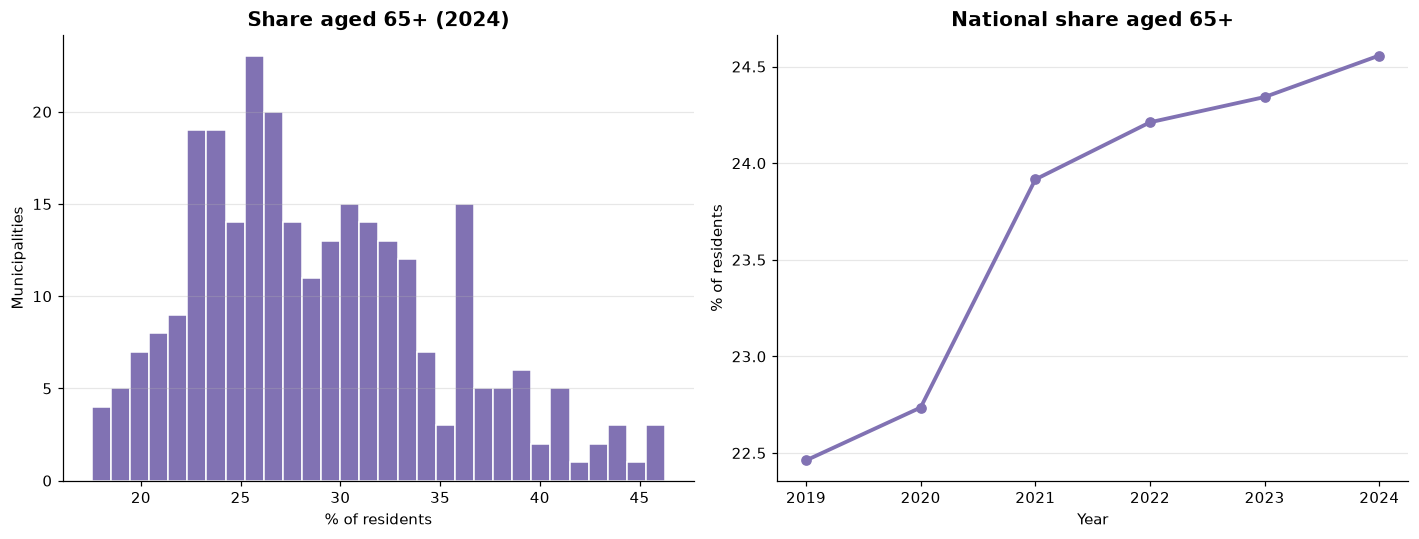

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(latest.share_65_plus, bins=30, color="#8172B3", edgecolor="white")
axes[0].set_title(f"Share aged 65+ ({int(latest.year.iloc[0])})")
axes[0].set_xlabel("% of residents")
axes[0].set_ylabel("Municipalities")

national = panel.groupby("year").apply(
    lambda g: (g.pop_65_plus.sum() / g.pop_total.sum()) * 100, include_groups=False
)
axes[1].plot(national.index, national.values, marker="o", linewidth=2.5, color="#8172B3")
axes[1].set_title("National share aged 65+")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of residents")

fig.tight_layout()
save_figure(fig, "ageing_distribution")
plt.show()

The oldest municipality has more than two and a half times the elderly share of
the youngest, and the ageing index ranges from 117 to 732 elderly per hundred
children. Population density spans three orders of magnitude. These are not small
differences to be controlled away — they are the variation the analysis rests on.

## Ageing and fire: the raw picture

Finally, the relationship the project is about — shown, not tested. No model is
fitted here.

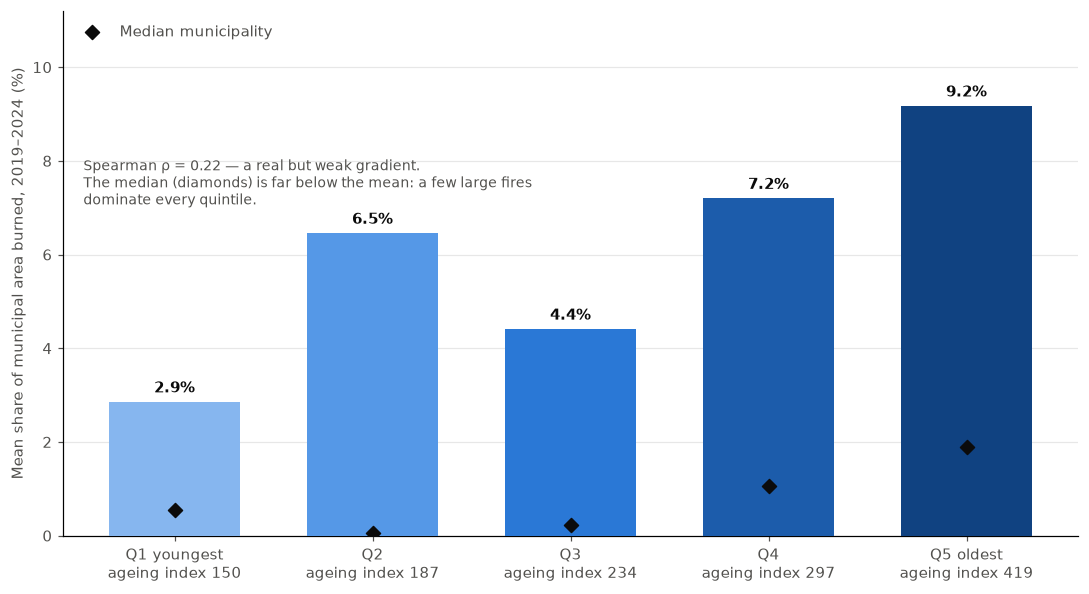

,n,mean_share,median_share,median_aging
aging,,,,
Q1 youngest,56,2.863,0.538,149.906
Q2,55,6.462,0.063,186.900
Q3,56,4.415,0.225,233.975
Q4,55,7.206,1.053,296.963
Q5 oldest,56,9.179,1.885,418.772


In [13]:
grouped, rho = quintile_data()

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_quintiles(fig, ax, grouped, rho)
fig.tight_layout()
save_figure(fig, "burnt_area_by_aging_quintile_ch02")
plt.show()

grouped.round(3)

The oldest fifth of municipalities burn a larger share of their own land than the
youngest fifth, on both the mean and the median. **The progression between them is
not monotone**, though: Q1 has a higher median share than either Q2 or Q3, so the
chart's story is "the oldest quintile stands out", not "burn share rises steadily
with age". The association is weak, and it is worth putting the several ways of
measuring it side by side rather than quoting whichever is largest.

In [14]:
by_municipality = municipal.set_index("dtcc")

pairs = [
    ("aging_index", "burn_rate_pct", "ageing vs annual burn rate"),
    ("aging_index", "lc_transit_mean", "ageing vs transitional woodland in burn scars"),
    ("lc_transit_mean", "burn_rate_pct", "transitional woodland vs annual burn rate"),
    ("pop_density", "burn_rate_pct", "population density vs annual burn rate"),
]

correlations = pd.DataFrame(
    [
        {
            "relationship": label,
            "spearman_rho": round(
                by_municipality[a].corr(by_municipality[b], method="spearman"), 4
            ),
            "n": int((by_municipality[a].notna() & by_municipality[b].notna()).sum()),
        }
        for a, b, label in pairs
    ]
)
correlations

,relationship,spearman_rho,n
0,ageing vs annual burn rate,0.1044,278
1,ageing vs transitional woodland in burn scars,-0.0176,209
2,transitional woodland vs annual burn rate,0.1645,209
3,population density vs annual burn rate,0.0779,278


## Takeaways

- **Four fifths of fires never reach one hectare; the 0.2% above 500 ha drive every
  burned-area total.** Any statistic built on fire counts describes the part of the
  distribution that does not do the damage.
- **The national ageing–fire correlation is a north–south composition effect, not a
  within-place association.** North of the Tejo is both older *and* burnier than the
  south, yet inside either half the relationship disappears (ρ ≈ 0.02 north,
  ρ ≈ −0.24 south). The national ρ ≈ 0.10 is the contrast *between* two regions —
  exactly the confound municipality fixed effects exist to absorb.
- **Ageing and the abandonment indicator are uncorrelated (ρ ≈ −0.02), so the
  hypothesised middle link is unmeasured.** `lc_transit_mean` describes burn-scar
  composition rather than municipal land cover, so it cannot stand in for
  abandonment. Any claim about that mechanism is inference, not evidence.
- **Ignitions decline over 2001–2025; long-duration and very large fires do not.**
  The share of fires burning beyond 24 hours does not follow the ignition count
  down, and 1000-hectare-plus fires are driven by a handful of catastrophic years.
  Fewer fires is not less fire.
- **EFFIS counts break at 2020 and cannot be compared across it.** 86 mapped fires
  in 2018 against 1,232 in 2022 is a change in what EFFIS chooses to map, not in
  fire activity; any comparison spanning it needs the constant size floor from
  chapter 01 applied first.